# Post-Pruning

This notebook computes the cost-complexity pruning path, evaluates 30 evenly spaced candidate alphas, and plots validation F1 against alpha.

## Planned Steps

- Load the encoded train and validation sets
- Fit a default decision tree with `random_state=42`
- Get candidate alphas from `cost_complexity_pruning_path`
- Select 30 alphas evenly spaced by index and evaluate each pruned tree
- Print a table of alpha, train F1, val F1, depth, and leaves
- Plot validation F1 versus alpha
- Refit the final post-pruned tree at `ccp_alpha=0.000890` and report train/validation metrics

   alpha  train_f1   val_f1  depth  leaves
0.000000  1.000000 0.848665     23     518
0.000171  0.997928 0.849741     23     490
0.000174  0.995543 0.852071     23     460
0.000178  0.993154 0.857143     23     430
0.000238  0.987733 0.857988     23     389
0.000238  0.987733 0.857988     23     389
0.000244  0.987249 0.860534     23     384
0.000268  0.983304 0.865185     23     354
0.000283  0.982529 0.865827     23     350
0.000286  0.980797 0.867701     23     338
0.000298  0.978257 0.868148     23     322
0.000306  0.973437 0.869436     20     293
0.000311  0.969967 0.868148     20     271
0.000317  0.966788 0.867701     18     251
0.000321  0.965244 0.869373     18     241
0.000327  0.958917 0.874074     18     202
0.000339  0.956079 0.875556     18     186
0.000354  0.952790 0.874631     18     171
0.000382  0.949244 0.871870     16     155
0.000419  0.944656 0.875184     16     134
0.000446  0.940016 0.877835     16     118
0.000471  0.936069 0.881232     15     105
0.000497  0

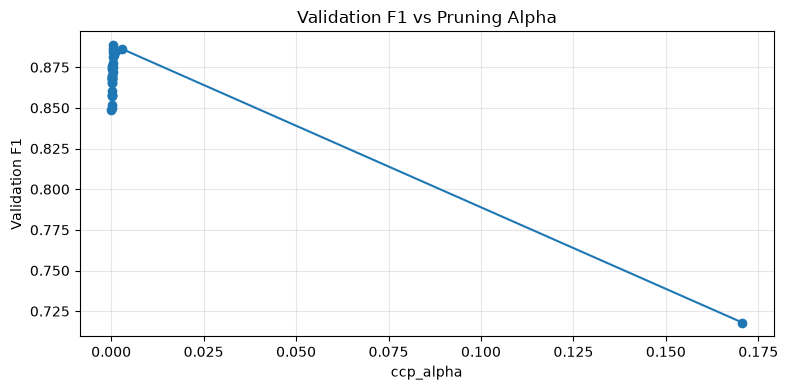


Final post-pruned tree
ccp_alpha: 0.000890
train_f1: 0.9036
val_f1: 0.8825
train_accuracy: 0.8912
depth: 9
leaves: 27


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier

TRAIN_PATH = Path('data/processed/encoded_train.csv')
VAL_PATH = Path('data/processed/encoded_validation.csv')

if not TRAIN_PATH.exists():
    TRAIN_PATH = Path('../data/processed/encoded_train.csv')
    VAL_PATH = Path('../data/processed/encoded_validation.csv')

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)

X_train = train_df.drop(columns=['Approval'])
y_train = train_df['Approval']
X_val = val_df.drop(columns=['Approval'])
y_val = val_df['Approval']

base_tree = DecisionTreeClassifier(random_state=42)
base_tree.fit(X_train, y_train)

path = base_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

if len(ccp_alphas) <= 30:
    selected_indices = np.arange(len(ccp_alphas))
else:
    selected_indices = np.linspace(0, len(ccp_alphas) - 1, 30).round().astype(int)
    selected_indices = np.unique(selected_indices)
    if selected_indices[0] != 0:
        selected_indices = np.insert(selected_indices, 0, 0)
    if selected_indices[-1] != len(ccp_alphas) - 1:
        selected_indices = np.append(selected_indices, len(ccp_alphas) - 1)
    selected_indices = np.unique(selected_indices)
    if len(selected_indices) > 30:
        selected_indices = np.linspace(0, len(selected_indices) - 1, 30).round().astype(int)

selected_alphas = ccp_alphas[selected_indices]

rows = []
for alpha in selected_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=float(alpha))
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    rows.append({
        'alpha': float(alpha),
        'train_f1': f1_score(y_train, train_pred, pos_label='Yes'),
        'val_f1': f1_score(y_val, val_pred, pos_label='Yes'),
        'depth': model.get_depth(),
        'leaves': model.get_n_leaves(),
    })

results_df = pd.DataFrame(rows).sort_values('alpha').reset_index(drop=True)
print(results_df.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.plot(results_df['alpha'], results_df['val_f1'], marker='o')
plt.xlabel('ccp_alpha')
plt.ylabel('Validation F1')
plt.title('Validation F1 vs Pruning Alpha')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

final_alpha = 0.000890
final_model = DecisionTreeClassifier(random_state=42, ccp_alpha=final_alpha)
final_model.fit(X_train, y_train)

final_train_pred = final_model.predict(X_train)
final_val_pred = final_model.predict(X_val)

print('\nFinal post-pruned tree')
print(f'ccp_alpha: {final_alpha:.6f}')
print(f"train_f1: {f1_score(y_train, final_train_pred, pos_label='Yes'):.4f}")
print(f"val_f1: {f1_score(y_val, final_val_pred, pos_label='Yes'):.4f}")
print(f"train_accuracy: {accuracy_score(y_train, final_train_pred):.4f}")
print(f'depth: {final_model.get_depth()}')
print(f'leaves: {final_model.get_n_leaves()}')
